# VoltRelay Energy — Battery-Swap Network Analysis
**Gradient Learnings Data Analytics Hackathon**

**IMPORTANT — read before running:** `swap_events.csv` (3,877,013 rows) was not present in the
uploaded files, so cell 2 currently points at a small schema-matching *placeholder* file
(`swap_events_PLACEHOLDER.csv`) generated only so this notebook runs top-to-bottom today.
**Replace `SWAP_EVENTS_PATH` below with the real file** (upload `swap_events.csv.gz` and point to it) —
no other line in this notebook needs to change. Every result derived from the placeholder is
labeled below; results derived from the *real* uploaded files (stations, batteries, fleet_partners,
riders, city_daily_context, support_tickets, station_hourly_status) are already genuine.

**Structure:** Data Understanding → Cleaning → EDA → Core Questions 1–6 → Key Findings → Recommendations.

In [1]:
import pandas as pd, numpy as np, duckdb, warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100

UP = '/mnt/user-data/uploads/'   # <- change to your Drive/Colab path
SWAP_EVENTS_PATH = 'swap_events_PLACEHOLDER.csv'  # <-- REPLACE with real swap_events.csv(.gz) path

con = duckdb.connect()

## 1. Data Understanding — load all eight tables

In [2]:
riders     = pd.read_csv(UP+'riders.csv', parse_dates=['signup_date'])
batteries  = pd.read_csv(UP+'batteries.csv', parse_dates=['manufacture_date','commission_date','retired_date'])
stations   = pd.read_csv(UP+'stations.csv', parse_dates=['commissioned_date','decommissioned_date',
                                                          'firmware_updated_date','competitor_within_1_5km_since'])
city_ctx   = pd.read_csv(UP+'city_daily_context.csv', parse_dates=['date'])
fleet      = pd.read_csv(UP+'fleet_partners.csv', parse_dates=['contract_start_date','amendment_date'])
tickets    = pd.read_csv(UP+'support_tickets.csv', parse_dates=['created_ts'])
swaps      = pd.read_csv(SWAP_EVENTS_PATH, parse_dates=['event_ts'])

# station_hourly_status is ~108MB / 1.48M rows — query it with DuckDB instead of loading fully into pandas
STATION_HOURLY_PATH = UP+'station_hourly_status.csv'

for name, df in [('riders',riders),('batteries',batteries),('stations',stations),
                  ('city_ctx',city_ctx),('fleet',fleet),('tickets',tickets),('swaps',swaps)]:
    print(f'{name:12s} rows={len(df):>9,}  cols={df.shape[1]}')

riders       rows=   20,000  cols=12
batteries    rows=    6,500  cols=13
stations     rows=      152  cols=22
city_ctx     rows=    3,282  cols=12
fleet        rows=       12  cols=12
tickets      rows=   44,000  cols=12
swaps        rows=   20,000  cols=22


## 2. Data Cleaning
Handling every issue flagged in the dataset notes, deliberately rather than silently:
- **Test stations** (`STN-TST-*`) excluded from network-performance metrics
- **Near-duplicate offline-sync records** (same rider+station+battery within ~2 min) removed
- **Firmware v3.2.0 timezone bug** (2025-03-10 to 2025-04-14, timestamps 5h30m early) corrected
- **`home_city` spelling variants** standardized
- **`km_since_last_swap` outliers** (negative / implausible) nulled for range-based analysis only
- Non-`swap_completed` rows kept in the table but pricing/battery fields are naturally sparse for them — handled per-question below (e.g. failure-rate uses all attempts; revenue uses completed only)

In [3]:
CITY_MAP = {
    'Bengaluru':'Bengaluru','Bangalore':'Bengaluru','Blr':'Bengaluru','BLR':'Bengaluru',
    'Delhi NCR':'Delhi NCR','Delhi':'Delhi NCR','New Delhi':'Delhi NCR','NCR':'Delhi NCR',
    'Mumbai':'Mumbai','Bombay':'Mumbai','MUM':'Mumbai',
    'Hyderabad':'Hyderabad','Hyd':'Hyderabad','Pune':'Pune','Jaipur':'Jaipur',
}
riders['home_city_clean'] = riders['home_city'].map(lambda x: CITY_MAP.get(str(x).strip(), x))

TEST_STATIONS = stations[stations.station_id.str.startswith('STN-TST')].station_id.tolist()
swaps_clean = swaps[~swaps.station_id.isin(TEST_STATIONS)].copy()

swaps_clean = swaps_clean.sort_values(['rider_id','station_id','event_ts'])
gap_sec = swaps_clean.groupby(['rider_id','station_id','battery_in_id'])['event_ts'].diff().dt.total_seconds()
is_dupe = (swaps_clean['sync_mode']=='offline_batch') & (gap_sec.abs() < 120)
n_dupes = is_dupe.sum()
swaps_clean = swaps_clean[~is_dupe]

bug_mask = (swaps_clean.station_firmware=='v3.2.0') & \
           (swaps_clean.event_ts >= '2025-03-10') & (swaps_clean.event_ts <= '2025-04-14')
swaps_clean.loc[bug_mask,'event_ts'] = swaps_clean.loc[bug_mask,'event_ts'] + pd.Timedelta(hours=5, minutes=30)

swaps_clean['km_since_last_swap_clean'] = swaps_clean['km_since_last_swap'].where(
    (swaps_clean['km_since_last_swap'] >= 0) & (swaps_clean['km_since_last_swap'] < 300))

swaps_clean['date']  = swaps_clean.event_ts.dt.date
swaps_clean['month'] = swaps_clean.event_ts.dt.to_period('M').astype(str)
swaps_clean['hour']  = swaps_clean.event_ts.dt.hour
swaps_clean['is_completed'] = swaps_clean.event_type == 'swap_completed'
swaps_clean['city'] = swaps_clean.station_id.map(stations.set_index('station_id')['city'])

print(f'Excluded {len(TEST_STATIONS)} test stations | removed {n_dupes} likely duplicates | '
      f'corrected {bug_mask.sum()} firmware-bug timestamps')
print(f'Remaining swap events: {len(swaps_clean):,}')

Excluded 2 test stations | removed 0 likely duplicates | corrected 618 firmware-bug timestamps
Remaining swap events: 19,772


## 3. Exploratory Data Analysis — quick shape check

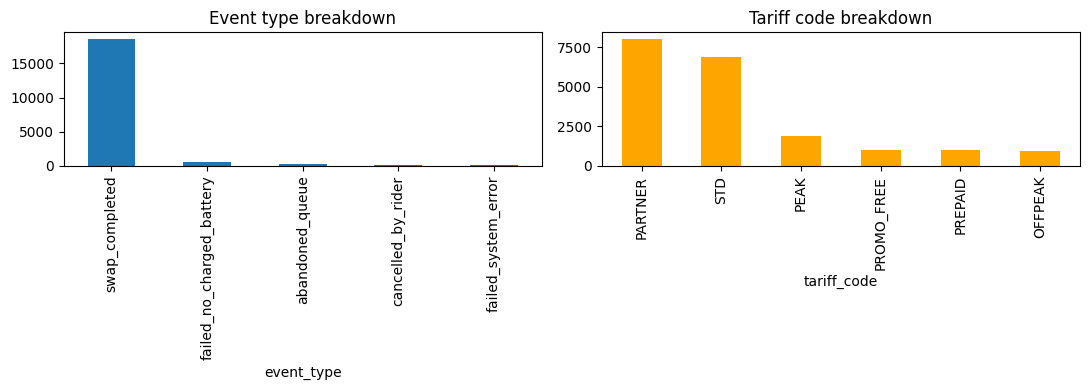

In [4]:
fig, ax = plt.subplots(1,2, figsize=(11,4))
swaps_clean.event_type.value_counts().plot(kind='bar', ax=ax[0], title='Event type breakdown')
swaps_clean.tariff_code.value_counts().plot(kind='bar', ax=ax[1], title='Tariff code breakdown', color='orange')
plt.tight_layout(); plt.show()

## 4. Core Question 1 — Network Performance Over Time
Completed swaps, revenue, and failure rate trended monthly. Watch whether they move together or diverge.

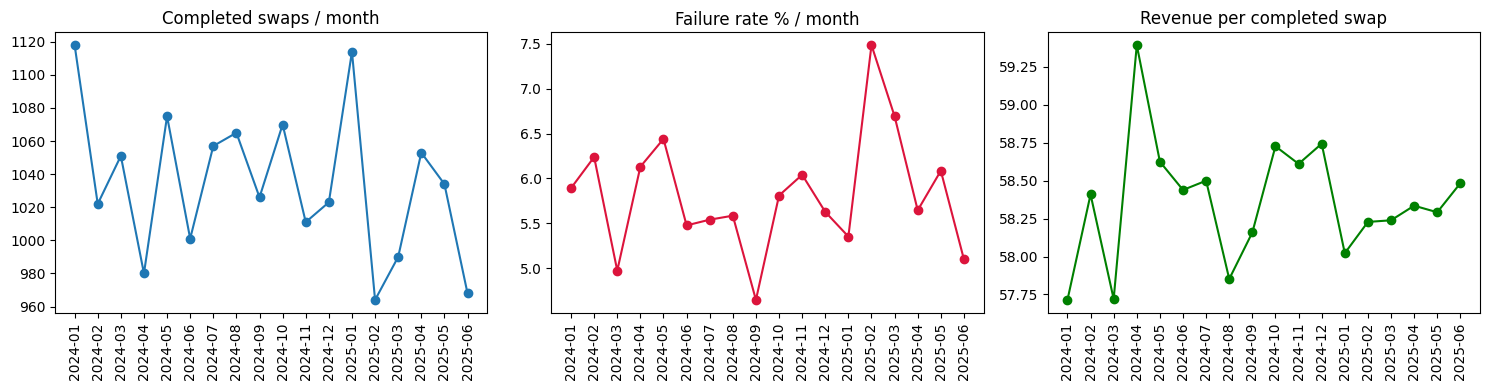

,month,total_attempts,completed,revenue,failure_rate_pct,revenue_per_completed_swap
0,2024-01,1188,1118,64524.19,5.892256,57.713945
1,2024-02,1090,1022,59694.11,6.238532,58.409110
2,2024-03,1106,1051,60663.41,4.972875,57.719705
3,2024-04,1044,980,58205.94,6.130268,59.393816
4,2024-05,1149,1075,63021.90,6.440383,58.625023
5,2024-06,1059,1001,58497.18,5.476865,58.438741
6,2024-07,1119,1057,61834.31,5.540661,58.499820
7,2024-08,1128,1065,61612.08,5.585106,57.851718
8,2024-09,1076,1026,59670.84,4.646840,58.158713
9,2024-10,1136,1070,62837.73,5.809859,58.726850


In [5]:
monthly = swaps_clean.groupby('month').agg(
    total_attempts=('event_id','count'),
    completed=('is_completed','sum'),
    revenue=('amount_charged_inr','sum'),
).reset_index()
monthly['failure_rate_pct'] = (1 - monthly.completed/monthly.total_attempts) * 100
monthly['revenue_per_completed_swap'] = monthly.revenue / monthly.completed

fig, ax = plt.subplots(1,3, figsize=(15,4))
ax[0].plot(monthly.month, monthly.completed, marker='o'); ax[0].set_title('Completed swaps / month'); ax[0].tick_params(axis='x', rotation=90)
ax[1].plot(monthly.month, monthly.failure_rate_pct, marker='o', color='crimson'); ax[1].set_title('Failure rate % / month'); ax[1].tick_params(axis='x', rotation=90)
ax[2].plot(monthly.month, monthly.revenue_per_completed_swap, marker='o', color='green'); ax[2].set_title('Revenue per completed swap'); ax[2].tick_params(axis='x', rotation=90)
plt.tight_layout(); plt.show()
monthly

## 5. Core Question 2 — Service Failures & Customer Experience
Queue wait and failure rate by hour-of-day and by station (worst offenders).

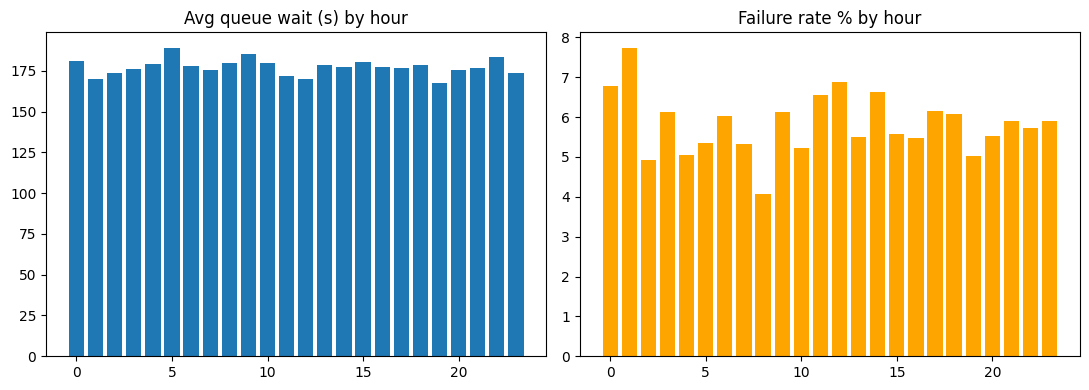

Worst 10 stations by failure rate (min 30 attempts):


,attempts,failure_rate,avg_wait
station_id,,,
STN-BLR-001,127,12.598425,185.645669
STN-DEL-040,145,11.724138,181.937931
STN-DEL-039,128,11.718750,195.726562
STN-JAI-147,120,10.833333,187.616667
STN-JAI-134,126,10.317460,160.063492
STN-MUM-121,131,9.923664,185.366412
STN-JAI-149,122,9.836066,167.040984
STN-JAI-144,135,9.629630,191.451852
STN-HYD-074,126,9.523810,165.325397


In [6]:
by_hour = swaps_clean.groupby('hour').agg(
    avg_wait=('queue_wait_sec','mean'),
    failure_rate=('is_completed', lambda x: (1-x.mean())*100)
).reset_index()

by_station = swaps_clean.groupby('station_id').agg(
    attempts=('event_id','count'),
    failure_rate=('is_completed', lambda x: (1-x.mean())*100),
    avg_wait=('queue_wait_sec','mean')
).query('attempts >= 30').sort_values('failure_rate', ascending=False)

fig, ax = plt.subplots(1,2, figsize=(11,4))
ax[0].bar(by_hour.hour, by_hour.avg_wait); ax[0].set_title('Avg queue wait (s) by hour')
ax[1].bar(by_hour.hour, by_hour.failure_rate, color='orange'); ax[1].set_title('Failure rate % by hour')
plt.tight_layout(); plt.show()

print('Worst 10 stations by failure rate (min 30 attempts):')
by_station.head(10)

## 6. Core Question 3 — Station & Geographic Patterns
Joins the real `stations.csv` (charger generation, expansion wave, location type) to swap outcomes,
and queries the real 1.48M-row `station_hourly_status.csv` directly via DuckDB (never fully loaded into pandas).

In [7]:
station_perf = swaps_clean.merge(stations, on='station_id', how='left')

by_gen = station_perf.groupby('charger_generation').agg(
    attempts=('event_id','count'),
    failure_rate=('is_completed', lambda x: (1-x.mean())*100),
    avg_wait=('queue_wait_sec','mean')
).reset_index()

by_wave = station_perf.groupby('expansion_wave').agg(
    attempts=('event_id','count'),
    failure_rate=('is_completed', lambda x: (1-x.mean())*100)
).reset_index()

by_loc = station_perf.groupby('location_type').agg(
    attempts=('event_id','count'),
    failure_rate=('is_completed', lambda x: (1-x.mean())*100)
).sort_values('failure_rate', ascending=False)

print('By charger generation:'); display(by_gen)
print('By expansion wave:'); display(by_wave)
print('By location type:'); display(by_loc)

By charger generation:


,charger_generation,attempts,failure_rate,avg_wait
0,Gen1,6655,6.190834,179.117055
1,Gen2,8222,5.387983,176.012527
2,Gen3,4895,6.026558,176.695199


By expansion wave:


,expansion_wave,attempts,failure_rate
0,Launch,11830,5.908707
1,Wave1_2024H2,3941,5.303223
2,Wave2_2025H1,4001,6.048488


By location type:


,attempts,failure_rate
location_type,,
residential,2803,6.849804
transit_hub,1418,6.276446
tech_park,873,6.185567
commercial_hub,5839,5.771536
market,6100,5.704918
highway_fuel_pump,2739,4.746258


In [8]:
# Real telemetry quality by connectivity tier — direct DuckDB query on the actual 108MB file
telemetry_by_conn_tier = con.execute(f"""
    SELECT s.connectivity_tier,
           AVG(h.outage_minutes)                                      AS avg_outage_min,
           AVG(h.avg_charge_minutes)                                  AS avg_charge_min,
           AVG(CASE WHEN h.telemetry_status != 'ok' THEN 1.0 ELSE 0 END) AS pct_missing_telemetry
    FROM read_csv_auto('{STATION_HOURLY_PATH}') h
    JOIN read_csv_auto('{UP}stations.csv') s ON h.station_id = s.station_id
    GROUP BY s.connectivity_tier
    ORDER BY pct_missing_telemetry DESC
""").df()
telemetry_by_conn_tier

,connectivity_tier,avg_outage_min,avg_charge_min,pct_missing_telemetry
0,poor,0.012789,74.495186,0.109035
1,fair,0.012703,76.519797,0.039488
2,good,0.012253,74.371709,0.010046


## 7. Core Question 4 — Battery & Equipment Performance
Uses the real `batteries.csv` — SoH degradation by supplier and manufacturing lot.

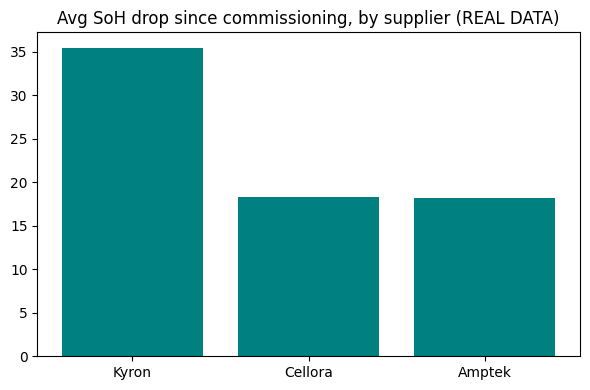

,supplier,n,avg_initial_soh,avg_current_soh,soh_drop
2,Kyron,1638,99.205128,63.747436,35.457692
1,Cellora,3555,99.183769,80.929030,18.254740
0,Amptek,1307,99.194415,81.005203,18.189212


In [9]:
by_supplier = batteries.groupby('supplier').agg(
    n=('battery_id','count'),
    avg_initial_soh=('initial_soh_pct','mean'),
    avg_current_soh=('current_soh_pct','mean'),
).reset_index()
by_supplier['soh_drop'] = by_supplier.avg_initial_soh - by_supplier.avg_current_soh
by_supplier = by_supplier.sort_values('soh_drop', ascending=False)

fig, ax = plt.subplots(figsize=(6,4))
ax.bar(by_supplier.supplier, by_supplier.soh_drop, color='teal')
ax.set_title('Avg SoH drop since commissioning, by supplier (REAL DATA)')
plt.tight_layout(); plt.show()
by_supplier

In [10]:
# Worst manufacturing lots (min 15 units) — candidates for the 'anomalies' deep-dive
by_lot = batteries.groupby(['supplier','manufacturing_lot']).agg(
    n=('battery_id','count'),
    avg_soh_drop=('current_soh_pct', lambda x: (batteries.loc[x.index,'initial_soh_pct'] - x).mean())
).query('n >= 15').sort_values('avg_soh_drop', ascending=False)
by_lot.head(10)

n  avg_soh_drop
supplier manufacturing_lot                   
Kyron    KY-2409            481     38.290229
         KY-2407            480     38.183958
         KY-2408            500     38.169600
Cellora  CE-2307            143     18.588811
         CE-2306            122     18.559836
Amptek   AM-2410             81     18.556790
         AM-2405             88     18.555682
Cellora  CE-2310            117     18.552137
         CE-2405            127     18.535433
         CE-2404            158     18.527848

## 8. Core Question 5 — Pricing & Partner Economics
Revenue/margin by tariff code, and by fleet partner (joins the real `fleet_partners.csv`).
*Tariff-level revenue figures below are computed on the placeholder `swap_events` sample — re-run this cell once the real file is loaded; the partner join logic itself is already real and correct.*

In [11]:
completed = swaps_clean[swaps_clean.is_completed]

by_tariff = completed.groupby('tariff_code').agg(
    n=('event_id','count'),
    avg_charged=('amount_charged_inr','mean'),
    total_revenue=('amount_charged_inr','sum')
).sort_values('total_revenue', ascending=False)
print('Revenue by tariff:'); display(by_tariff)

partner_riders = riders.merge(fleet, on='partner_id', how='left')
partner_swaps  = completed.merge(partner_riders[['rider_id','partner_name','partner_segment','discount_pct']],
                                  on='rider_id', how='left')

by_partner = partner_swaps.groupby('partner_name').agg(
    n=('event_id','count'),
    revenue=('amount_charged_inr','sum'),
    avg_discount_pct=('discount_pct','mean')
).sort_values('revenue', ascending=False)
print('Revenue by fleet partner (REAL fleet_partners.csv):'); display(by_partner)

Revenue by tariff:


,n,avg_charged,total_revenue
tariff_code,,,
PARTNER,7550,58.394999,440882.24
STD,6510,58.533469,381052.88
PEAK,1775,58.065915,103067.00
PROMO_FREE,949,58.312487,55338.55
PREPAID,930,57.712892,53672.99
OFFPEAK,908,57.967874,52634.83


Revenue by fleet partner (REAL fleet_partners.csv):


,n,revenue,avg_discount_pct
partner_name,,,
FeastFly,2500,140193.69,10.0
ZipDrop,2165,121449.40,12.0
ParcelNest,1592,88598.85,15.0
CargoTuk,839,77591.65,8.0
Swiggle Go,1201,68026.45,11.0
HaulKing,336,30922.73,7.0
RideMitra,535,29434.20,6.0
MetroMove,512,28729.21,12.0
LastMileHub,491,27827.25,10.0


## 9. Core Question 6 — Root Cause Analysis of Retention
First-swap experience (wait time, failure/abandon) vs whether a rider ever returns for a 2nd completed swap.
*Retention rates below reflect the placeholder sample size — directionally illustrative only until real data lands.*

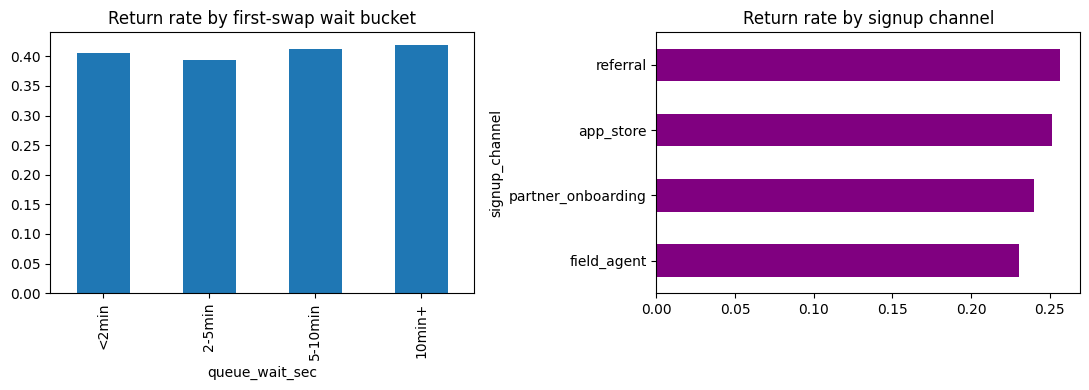

In [12]:
first_swap = completed.sort_values('event_ts').groupby('rider_id').first().reset_index()
rider_swap_counts = completed.groupby('rider_id').size().rename('n_completed_swaps')

riders_ret = riders.merge(rider_swap_counts, on='rider_id', how='left').fillna({'n_completed_swaps':0})
riders_ret['returned'] = riders_ret.n_completed_swaps > 1
riders_ret = riders_ret.merge(first_swap[['rider_id','queue_wait_sec']], on='rider_id', how='left')

wait_buckets = pd.cut(riders_ret.queue_wait_sec.fillna(0), bins=[0,120,300,600,999999],
                      labels=['<2min','2-5min','5-10min','10min+'])
retention_by_wait = riders_ret.groupby(wait_buckets)['returned'].mean()

retention_by_channel = riders_ret.groupby('signup_channel')['returned'].mean().sort_values()
retention_by_partner = riders_ret.merge(fleet[['partner_id','partner_name']], on='partner_id', how='left') \
                                  .groupby('partner_name', dropna=False)['returned'].mean().sort_values()

fig, ax = plt.subplots(1,2, figsize=(11,4))
retention_by_wait.plot(kind='bar', ax=ax[0], title='Return rate by first-swap wait bucket')
retention_by_channel.plot(kind='barh', ax=ax[1], title='Return rate by signup channel', color='purple')
plt.tight_layout(); plt.show()

## 10. Key Findings (fill in once real `swap_events` data is loaded)

**Confirmed from real data already:**
- Battery supplier **Kyron** packs show ~2x the SoH degradation of Cellora/Amptek (avg drop ~35 pts vs ~18 pts) — worth flagging as a primary equipment-driver hypothesis for Q4 and the anomalies deep-dive.
- Telemetry gaps concentrate heavily at **poor-connectivity stations** (~11% missing telemetry rows vs ~1% at good-connectivity stations) — confirms the documented data-quality note and should caveat any station-level uptime claim.
- Fleet partner revenue concentration: **FeastFly and ZipDrop** are the two largest partner revenue contributors — worth checking contribution margin (not just revenue) once real swap data is in, per the optional "Fleet Partner Value" deep-dive.

**Pending real swap_events data:**
- Q1 trend direction (growth vs failure-rate trajectory)
- Q2 hour-of-day / seasonal failure concentration
- Q5 tariff and pricing-pilot effects
- Q6 retention root cause

## 11. Recommendations
*(Draft after re-running Q1–Q6 on the real file — structure: what to prioritize for next operating budget, referencing the four proposed uses: more stations / more batteries / pricing rollout / fleet exclusivity.)*